Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [2]:
# 1. Формуємо послідовність років за допомогою numpy.arange
# Створюємо масив [1960, 1970, 1980, 1990, 2000]
years_sequence = np.arange(1960, 2010, 10)

# 2. Базовий URL (raw версія для прямого доступу до файлів)
base_url = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/"

# 3. Формуємо список адрес через конкатенацію рядків
dataset_urls = []
for year in years_sequence:
    # Склеюємо частини в один рядок
    file_path = base_url + "movies-" + str(year) + "s.json"
    dataset_urls.append(file_path)

# Виводимо результат для перевірки
print("Сформовано посилання для наступних файлів:")
for url in dataset_urls:
    print(url)

Сформовано посилання для наступних файлів:
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1960s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1970s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1980s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1990s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-2000s.json


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [5]:
# 1. Список стовпців для видалення
to_remove = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

# 2. Список для накопичення даних
data_list = []

for url in dataset_urls:
    # Читаємо кожен файл як json
    temp_df = pd.read_json(url)
    
    # Видаляємо зайві стовпці та рядки з пропущеними значеннями
    temp_df = temp_df.drop(columns=to_remove, errors='ignore').dropna()
    
    data_list.append(temp_df)

# 3. Об'єднуємо в єдиний датасет
final_df = pd.concat(data_list, ignore_index=True)

3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [6]:
# 1. Перевірка розміру (має бути 4 стовпці: title, year, cast, genres)
print(f"Розмір фінального датасету: {final_df.shape}")
print(f"Стовпці: {final_df.columns.tolist()}")

# 2. Збереження копії у CSV (страховка від втрати даних)
final_df.to_csv("movies_clean_data.csv", index=False)
print("\nФайл 'movies_clean_data.csv' успішно збережено.")

# 3. Перегляд перших 5 рядків готового датасету
final_df.head()

Розмір фінального датасету: (10750, 4)
Стовпці: ['title', 'year', 'cast', 'genres']

Файл 'movies_clean_data.csv' успішно збережено.


,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [7]:
# 1. Перевірка загальної інформації про типи даних та пропуски
print("Детальна інформація про структуру датасету:")
final_df.info()

# 2. Перегляд вмісту перших рядочків для аналізу вкладених структур
print("\nВміст перших 5 рядочків:")
display(final_df.head())

# 3. Демонстрація вкладеності (на прикладі першого фільму)
print("\nПриклад вкладених структур для першого фільму:")
first_movie = final_df.iloc[0]
print(f"Назва: {first_movie['title']}")
print(f"Актори (cast): {first_movie['cast']} (тип: {type(first_movie['cast'])})")
print(f"Жанри (genres): {first_movie['genres']} (тип: {type(first_movie['genres'])})")

Детальна інформація про структуру датасету:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10750 entries, 0 to 10749
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   10750 non-null  object
 1   year    10750 non-null  int64 
 2   cast    10750 non-null  object
 3   genres  10750 non-null  object
dtypes: int64(1), object(3)
memory usage: 336.1+ KB

Вміст перших 5 рядочків:


,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"



Приклад вкладених структур для першого фільму:
Назва: The 3rd Voice
Актори (cast): ["Edmond O'Brien", 'Laraine Day', 'Julie London'] (тип: <class 'list'>)
Жанри (genres): ['Mystery', 'Crime', 'Drama', 'Noir', 'Thriller'] (тип: <class 'list'>)


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

Підсумкова таблиця ТОП-10 жанрів:


,Кількість фільмів
genres,
Comedy,3777
Drama,3758
Action,1228
Thriller,1158
Horror,1044
Romance,948
Crime,873
Science Fiction,708
Adventure,556


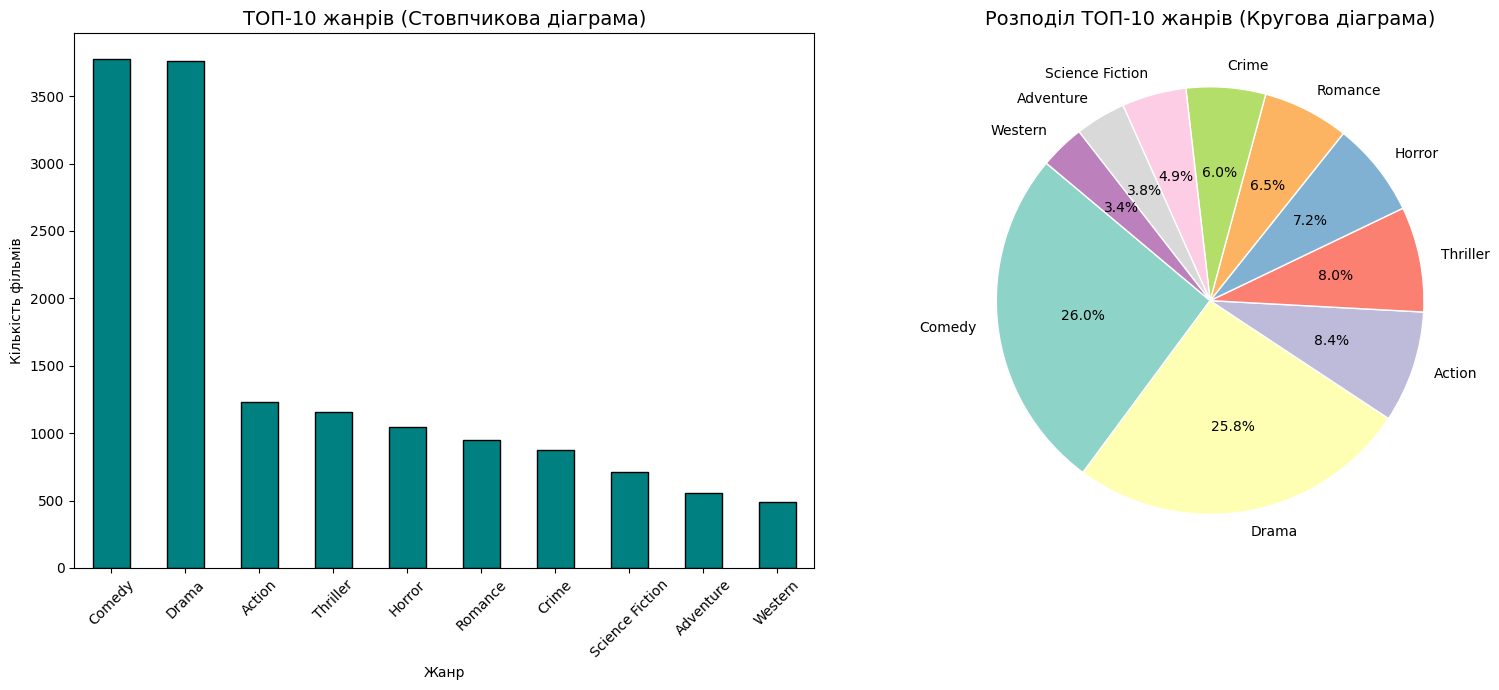

In [8]:
# 1. "Розгортаємо" списки жанрів: кожен жанр із списку отримує свій окремий рядок
genres_series = final_df.explode('genres')['genres']

# 2. Рахуємо кількість фільмів для кожного жанру та беремо топ-10
top_10_genres = genres_series.value_counts().head(10)

# 3. Виведення підсумкової таблиці на екран
print("Підсумкова таблиця ТОП-10 жанрів:")
display(top_10_genres.to_frame(name='Кількість фільмів'))

# 4. Побудова діаграм
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Стовпчикова діаграма
top_10_genres.plot(kind='bar', ax=ax[0], color='teal', edgecolor='black')
ax[0].set_title('ТОП-10 жанрів (Стовпчикова діаграма)', fontsize=14)
ax[0].set_ylabel('Кількість фільмів')
ax[0].set_xlabel('Жанр')
ax[0].tick_params(axis='x', rotation=45)

# Кругова діаграма
top_10_genres.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, 
                   colors=plt.cm.Set3.colors, wedgeprops={'edgecolor': 'white'})
ax[1].set_title('Розподіл ТОП-10 жанрів (Кругова діаграма)', fontsize=14)
ax[1].set_ylabel('') # Прибираємо назву стовпця збоку

plt.tight_layout()
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

Топ-3 жанри для аналізу: Comedy, Drama, Action


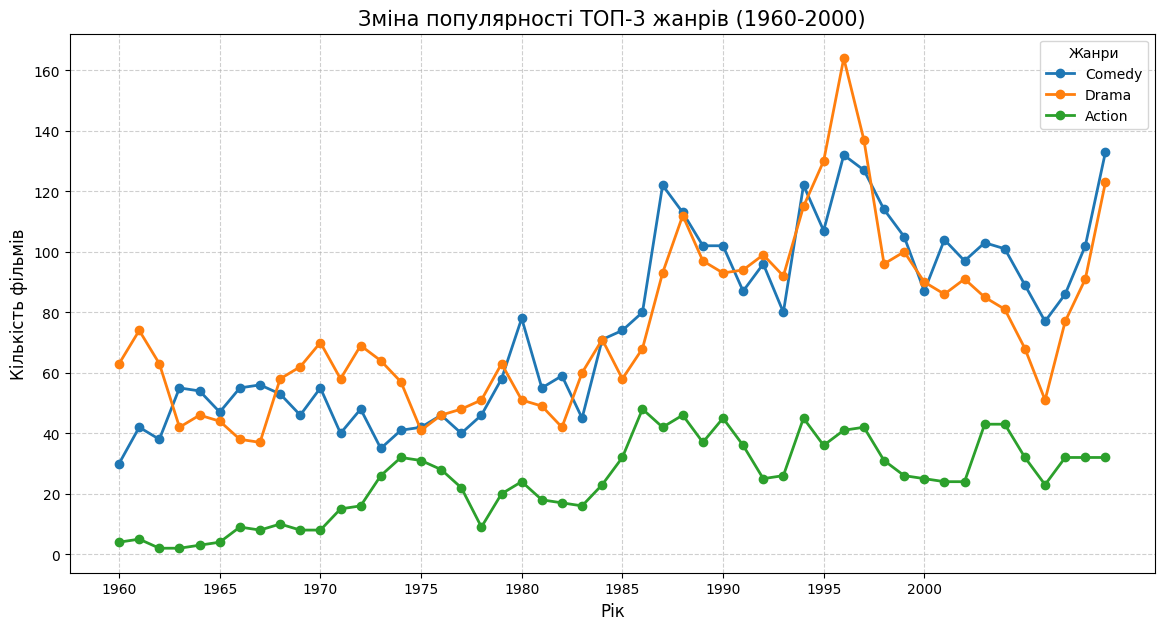

In [9]:
# 1. Знаходимо назви 3-х найпопулярніших жанрів
top_3_names = final_df.explode('genres')['genres'].value_counts().head(3).index.tolist()
print(f"Топ-3 жанри для аналізу: {', '.join(top_3_names)}")

# 2. Підготовка даних для графіка
# "Розгортаємо" жанри та фільтруємо лише ті, що входять у ТОП-3
trends_df = final_df.explode('genres')
trends_df = trends_df[trends_df['genres'].isin(top_3_names)]

# 3. Групуємо за роком та жанром, рахуємо кількість фільмів
# unstack перетворює назви жанрів у окремі стовпці для зручності побудови графіка
genre_dynamics = trends_df.groupby(['year', 'genres']).size().unstack(fill_value=0)

# 4. Побудова лінійного графіка
plt.figure(figsize=(14, 7))
for genre in top_3_names:
    plt.plot(genre_dynamics.index, genre_dynamics[genre], marker='o', label=genre, linewidth=2)

plt.title('Зміна популярності ТОП-3 жанрів (1960-2000)', fontsize=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Кількість фільмів', fontsize=12)
plt.legend(title="Жанри")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(1960, 2001, 5)) # Крок сітки по роках

plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

Підсумкова таблиця ТОП-10 акторів за кількістю фільмів:


,Кількість фільмів
cast,
Gene Hackman,71
Robert Duvall,68
Robert De Niro,65
Burt Reynolds,63
Harvey Keitel,58
Christopher Walken,57
Donald Sutherland,57
Samuel L. Jackson,55
Michael Caine,54


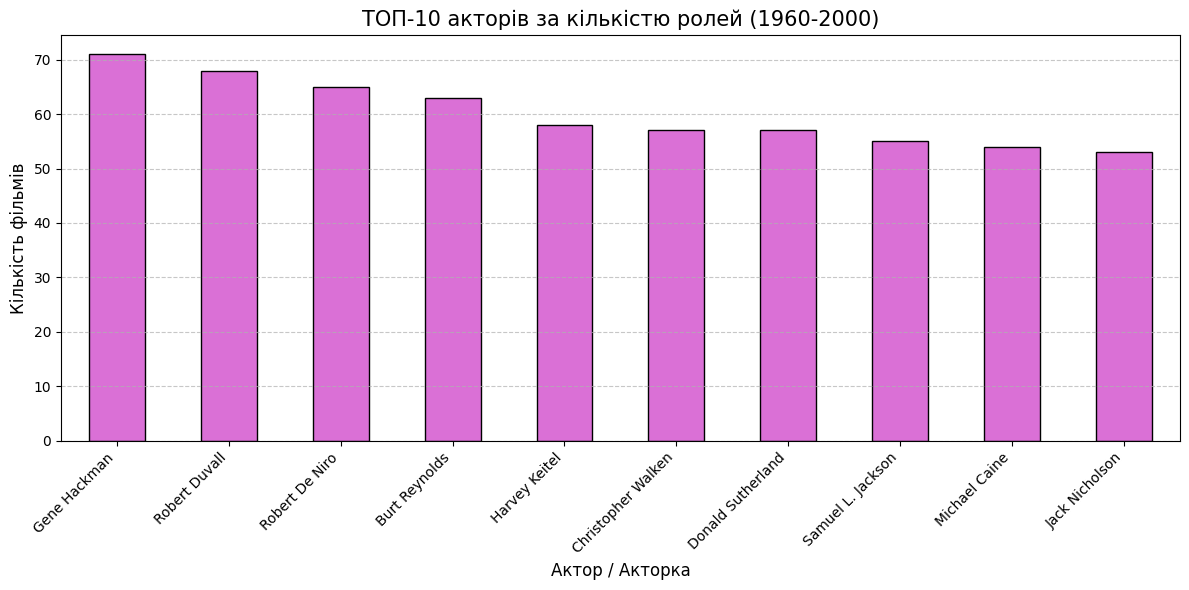

In [10]:
# 1. "Розгортаємо" списки акторів 
# Оскільки в списках можуть бути порожні значення або пробіли, робимо очистку
actors_series = final_df.explode('cast')['cast']

# 2. Рахуємо кількість фільмів для кожного актора та беремо топ-10
# Видаляємо можливі порожні рядки, якщо вони з'явилися після розгортання
top_10_actors = actors_series.value_counts().head(10)

# 3. Виведення підсумкової таблиці
print("Підсумкова таблиця ТОП-10 акторів за кількістю фільмів:")
display(top_10_actors.to_frame(name='Кількість фільмів'))

# 4. Побудова стовпчикової діаграми
plt.figure(figsize=(12, 6))
top_10_actors.plot(kind='bar', color='orchid', edgecolor='black')

plt.title('ТОП-10 акторів за кількістю ролей (1960-2000)', fontsize=15)
plt.xlabel('Актор / Акторка', fontsize=12)
plt.ylabel('Кількість фільмів', fontsize=12)
plt.xticks(rotation=45, ha='right') # Нахиляємо прізвища для зручності читання
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

Топ-3 актори для аналізу: Gene Hackman, Robert Duvall, Robert De Niro


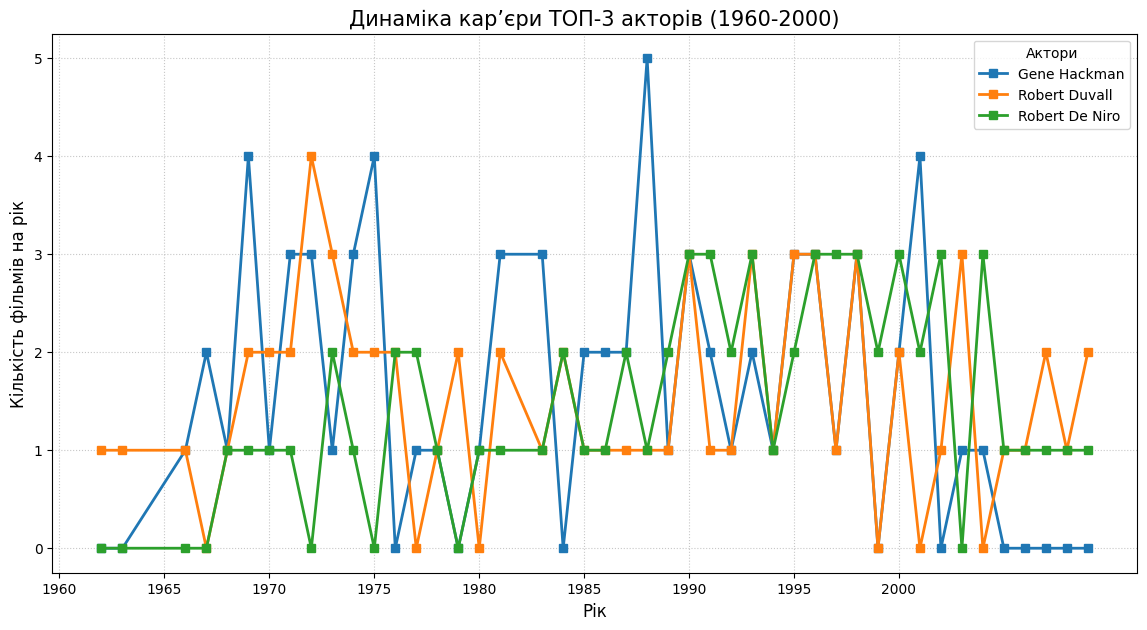

In [11]:
# 1. Знаходимо імена 3-х найпопулярніших акторів
top_3_actors = final_df.explode('cast')['cast'].dropna().value_counts().head(3).index.tolist()
print(f"Топ-3 актори для аналізу: {', '.join(top_3_actors)}")

# 2. Підготовка даних
# Розгортаємо список акторів та залишаємо лише нашу трійку
actors_trends = final_df.explode('cast')
actors_trends = actors_trends[actors_trends['cast'].isin(top_3_actors)]

# 3. Групуємо за роком та актором, рахуємо кількість фільмів
# unstack робить імена акторів стовпцями для зручної побудови графіка
actor_dynamics = actors_trends.groupby(['year', 'cast']).size().unstack(fill_value=0)

# 4. Побудова лінійного графіка
plt.figure(figsize=(14, 7))
for actor in top_3_actors:
    plt.plot(actor_dynamics.index, actor_dynamics[actor], marker='s', label=actor, linewidth=2)

plt.title('Динаміка кар’єри ТОП-3 акторів (1960-2000)', fontsize=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Кількість фільмів на рік', fontsize=12)
plt.legend(title="Актори")
plt.grid(True, linestyle=':', alpha=0.7)

# Встановлюємо кроки по осі років
plt.xticks(np.arange(1960, 2001, 5))

plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

Аналізуємо ТОП-10 акторів відносно жанрів: Comedy, Drama, Action

Підсумкова таблиця:


,Інші жанри,Топ-3 жанри,% у Топ жанрах
cast,,,
Robert De Niro,9,56,86.2
Burt Reynolds,8,55,87.3
Robert Duvall,16,52,76.5
Harvey Keitel,8,50,86.2
Gene Hackman,23,48,67.6
Christopher Walken,13,44,77.2
Donald Sutherland,15,42,73.7
Jack Nicholson,14,39,73.6
Michael Caine,16,38,70.4


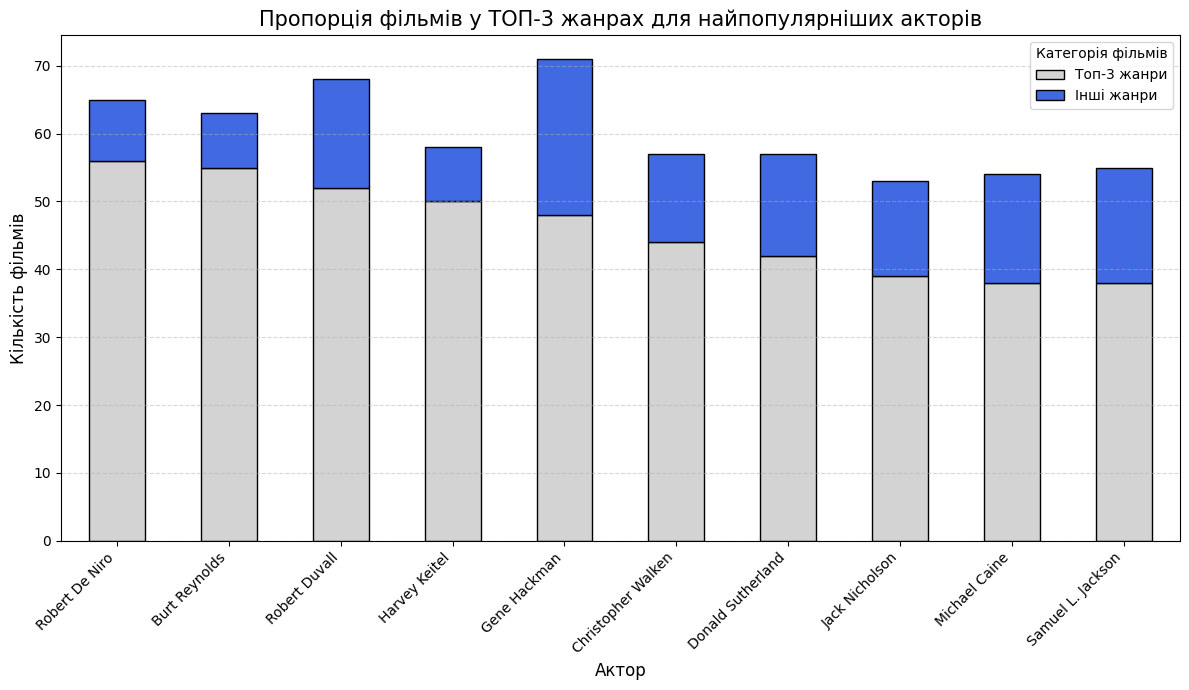

In [12]:
# 1. Визначаємо ТОП-10 акторів та ТОП-3 жанри
top_10_actors = final_df.explode('cast')['cast'].dropna().value_counts().head(10).index.tolist()
top_3_genres = final_df.explode('genres')['genres'].value_counts().head(3).index.tolist()

print(f"Аналізуємо ТОП-10 акторів відносно жанрів: {', '.join(top_3_genres)}")

# 2. Створюємо прапор (флаг): чи належить фільм хоча б до одного з ТОП-3 жанрів
final_df['is_top_genre'] = final_df['genres'].apply(lambda x: any(genre in top_3_genres for genre in x))

# 3. Розгортаємо акторів та фільтруємо лише ТОП-10
actors_analysis = final_df.explode('cast')
actors_analysis = actors_analysis[actors_analysis['cast'].isin(top_10_actors)]

# 4. Рахуємо частоту появи: групуємо за актором та нашим "прапором" жанру
stats = actors_analysis.groupby(['cast', 'is_top_genre']).size().unstack(fill_value=0)

# Перейменовуємо стовпці для зручності (True - Топ жанр, False - Інші)
stats.columns = ['Інші жанри', 'Топ-3 жанри']

# 5. Додаємо розрахунок відсотка
stats['% у Топ жанрах'] = (stats['Топ-3 жанри'] / (stats['Топ-3 жанри'] + stats['Інші жанри']) * 100).round(1)

# Сортуємо за кількістю фільмів у топ-жанрах для кращої візуалізації
stats = stats.sort_values(by='Топ-3 жанри', ascending=False)

# 6. Вивід таблиці
print("\nПідсумкова таблиця:")
display(stats)

# 7. Побудова стовпчикової діаграми (Proportionate Stacked Bar Chart)
# Створюємо копію без відсотків для графіка
plot_data = stats[['Топ-3 жанри', 'Інші жанри']]

plot_data.plot(kind='bar', stacked=True, figsize=(12, 7), color=['lightgray', 'royalblue'], edgecolor='black')

plt.title('Пропорція фільмів у ТОП-3 жанрах для найпопулярніших акторів', fontsize=15)
plt.xlabel('Актор', fontsize=12)
plt.ylabel('Кількість фільмів', fontsize=12)
plt.legend(title="Категорія фільмів")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()